# *Lepidonotopodium piscesae* — Median Abundance Analysis

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This notebook implements the median-per-video abundance method recommended by the lab group. Rather than relying on a single frame or tracking individuals, every frame across the full 15-minute Scene 1 window is used. The **median worm count per frame within each video** becomes the abundance estimate for that recording. Stringing those medians together produces a time series of abundance proxies across the full month.

**Why median instead of mean?**
The median is resistant to outliers. Frames where the camera briefly shifts position, or where a worm clusters unusually, will not skew the estimate the way they would with a mean. The median represents the most *typical* frame in that video.

**Workflow:**
1. **Setup** — configure paths and parameters
2. **Run YOLO on all Scene 1 frames** — detect scale worms in every frame of every video
3. **Compute median per video** — summarize each video as a single abundance value
4. **Plot abundance over time** — visualize the monthly trend
5. **Load manual VIAME annotations** — parse the expert-annotated CSVs
6. **Manual vs AI comparison** — compare distributions of per-frame counts between human and model

</span>

## 1. Setup

<span style="font-family: 'Courier New', monospace;">

Run this cell first every time you open the notebook. It imports all required libraries, sets directory paths, and defines the color palette used in all charts. Check the printed output to confirm the model file, video archive, and annotation directory are all found at their expected paths.

</span>

In [1]:
import re
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e9c46a',
    'xtick.color':      '#e9c46a',
    'ytick.color':      '#e9c46a',
    'text.color':       '#e9c46a',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

TEAL   = '#2ec4b6'
ORANGE = '#e76f51'
GOLD   = '#e9c46a'
BLUE   = '#457b9d'

# ── Paths ────────────────────────────────────────────────────────────
MODEL_PATH = Path("/home/jovyan/scaleworm-student-lab/mushroom.pt")
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/")
ANNOT_DIR  = Path("/home/jovyan/scaleworm_starter/baseline/annotations_scene1")
WORK_DIR   = Path("./median_abundance_session")
FRAMES_DIR = WORK_DIR / "frames"
EXPORT_DIR = WORK_DIR / "export"

for d in [WORK_DIR, FRAMES_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Video parameters ─────────────────────────────────────────────────
SCENE1_START_SEC    = 305
SCENE1_DURATION_SEC = 15
FPS                 = 1       # 1 fps = 15 frames per video over 15 seconds
FRAME_W, FRAME_H    = 1920, 1080
CONF_THRESHOLD      = 0.3
MAX_BOX_SIZE        = 300

STANDARD_TIMES = {
    "T001500", "T031500", "T061500", "T091500",
    "T121500", "T151500", "T181500", "T211500",
}

print(f"Model       : {MODEL_PATH}  |  exists: {MODEL_PATH.exists()}")
print(f"Video root  : {VIDEO_ROOT}  |  exists: {VIDEO_ROOT.exists()}")
print(f"Annotations : {ANNOT_DIR}  |  exists: {ANNOT_DIR.exists()}")
print(f"Work dir    : {WORK_DIR.resolve()}")

Model       : /home/jovyan/scaleworm-student-lab/mushroom.pt  |  exists: True
Video root  : /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301  |  exists: True
Annotations : /home/jovyan/scaleworm_starter/baseline/annotations_scene1  |  exists: True
Work dir    : /home/jovyan/scaleworm-student-lab/notebooks/median_abundance_session


## 2. Select Date Range and Find Videos

<span style="font-family: 'Courier New', monospace;">

Set your start and end dates below. The cell will scan the video archive and list all standard-cadence CAMHD videos in that range. CAMHD records at 8 fixed times per day (every 3 hours UTC), so a full month should return approximately 240 videos.

</span>

In [2]:
import datetime as dt

# ════════════════════════════════════════════════════════════════════
# ▼▼▼  SET YOUR DATE RANGE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════════════

START_DATE = "2024-10-01"
END_DATE   = "2024-10-31"

# ════════════════════════════════════════════════════════════════════

d_start = dt.date.fromisoformat(START_DATE)
d_end   = dt.date.fromisoformat(END_DATE)

videos = []
for mp4 in sorted(VIDEO_ROOT.rglob("CAMHDA301-*.mp4")):
    m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})T(\d{6})", mp4.name)
    if not m:
        continue
    file_date = dt.date(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    if file_date < d_start or file_date > d_end:
        continue
    if f"T{m.group(4)}" not in STANDARD_TIMES:
        continue
    videos.append(mp4)

videos = sorted(videos)
print(f"Found {len(videos)} videos between {START_DATE} and {END_DATE}")
for v in videos[:10]:
    print(f"  {v.name}")
if len(videos) > 10:
    print(f"  ... and {len(videos)-10} more")

Found 247 videos between 2024-10-01 and 2024-10-31
  CAMHDA301-20241001T031500.mp4
  CAMHDA301-20241001T061500.mp4
  CAMHDA301-20241001T091500.mp4
  CAMHDA301-20241001T121500.mp4
  CAMHDA301-20241001T151500.mp4
  CAMHDA301-20241001T181500.mp4
  CAMHDA301-20241001T211500.mp4
  CAMHDA301-20241002T001500.mp4
  CAMHDA301-20241002T031500.mp4
  CAMHDA301-20241002T061500.mp4
  ... and 237 more


## 3. Extract Scene 1 Frames

<span style="font-family: 'Courier New', monospace;">

Each CAMHD video is ~25 minutes long. Scene 1 (305–320 seconds) is when the camera zooms in on the Mushroom vent chimney — the primary habitat of *Lepidonotopodium piscesae*. This cell extracts frames from that 15-second window at 1 frame per second, giving 15 frames per video. Frames that already exist on disk are skipped, so this cell is safe to rerun.

**Expected output:** A progress list showing each video and frame count. Total should be approximately `number of videos × 15`.

</span>

In [3]:
def extract_scene1_frames(video_path, output_dir):
    """Extract Scene 1 frames via ffmpeg. Returns frame count."""
    output_dir.mkdir(parents=True, exist_ok=True)
    existing = sorted(output_dir.glob("frame_*.png"))
    if len(existing) >= FPS * SCENE1_DURATION_SEC - 1:
        return len(existing)
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(SCENE1_START_SEC),
        "-i", str(video_path),
        "-t", str(SCENE1_DURATION_SEC),
        "-vf", f"fps={FPS}",
        "-q:v", "2",
        str(output_dir / "frame_%04d.png"),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    if result.returncode != 0:
        print(f"  ERROR: {video_path.name}: {result.stderr[-200:]}")
        return 0
    return len(sorted(output_dir.glob("frame_*.png")))


video_frame_dirs = {}
total_frames     = 0

for i, vpath in enumerate(videos):
    vid_name  = vpath.stem
    frame_dir = FRAMES_DIR / vid_name
    video_frame_dirs[vid_name] = frame_dir
    n = extract_scene1_frames(vpath, frame_dir)
    total_frames += n
    print(f"  [{i+1}/{len(videos)}] {vid_name}: {n} frames")

print(f"\nTotal: {total_frames} frames from {len(videos)} videos")

  [1/247] CAMHDA301-20241001T031500: 15 frames
  [2/247] CAMHDA301-20241001T061500: 15 frames
  [3/247] CAMHDA301-20241001T091500: 15 frames
  [4/247] CAMHDA301-20241001T121500: 15 frames
  [5/247] CAMHDA301-20241001T151500: 15 frames
  [6/247] CAMHDA301-20241001T181500: 15 frames
  [7/247] CAMHDA301-20241001T211500: 15 frames
  [8/247] CAMHDA301-20241002T001500: 15 frames
  [9/247] CAMHDA301-20241002T031500: 15 frames
  [10/247] CAMHDA301-20241002T061500: 15 frames
  [11/247] CAMHDA301-20241002T091500: 15 frames
  [12/247] CAMHDA301-20241002T121500: 15 frames
  [13/247] CAMHDA301-20241002T151500: 15 frames
  [14/247] CAMHDA301-20241002T181500: 15 frames
  [15/247] CAMHDA301-20241002T211500: 15 frames
  [16/247] CAMHDA301-20241003T001500: 15 frames
  [17/247] CAMHDA301-20241003T031500: 15 frames
  [18/247] CAMHDA301-20241003T061500: 15 frames
  [19/247] CAMHDA301-20241003T091500: 15 frames
  [20/247] CAMHDA301-20241003T121500: 15 frames
  [21/247] CAMHDA301-20241003T151500: 15 frames
 

## 4. Run YOLO on All Scene 1 Frames

<span style="font-family: 'Courier New', monospace;">

The Mushroom Model is run on every extracted frame. For each frame, the number of scale worm detections above the confidence threshold is recorded. No tracking is applied here — each frame is treated as independent. The goal is to build a **distribution of per-frame worm counts** for each video, which is then summarized by its median in the next step.

This cell may take several minutes depending on the number of videos. Results are stored in a DataFrame with one row per frame.

**Expected output:** A progress list per video, then a preview of the results table.

</span>

In [4]:
!pip install ultralytics -q

In [5]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))
print(f"Loaded: {MODEL_PATH.name}\n")

frame_records = []   # one row per frame
FNAME_REGEX   = re.compile(r"(\d{8})T(\d{6})")

for vid_name, frame_dir in sorted(video_frame_dirs.items()):
    frames = sorted(frame_dir.glob("frame_*.png"))
    if not frames:
        continue

    m = FNAME_REGEX.search(vid_name)
    if not m:
        continue
    vid_date = pd.to_datetime(m.group(1), format='%Y%m%d').date()
    vid_time = m.group(2)   # HHMMSS
    vid_dt   = datetime.strptime(f"{m.group(1)}{m.group(2)}", "%Y%m%d%H%M%S")

    results = model.predict(
        source=[str(f) for f in frames],
        conf=CONF_THRESHOLD,
        verbose=False,
        stream=True,
    )

    frame_counts = []
    for frame_idx, (frame_path, result) in enumerate(zip(frames, results)):
        boxes = result.boxes
        count = 0
        if boxes is not None and len(boxes) > 0:
            for box, conf in zip(boxes.xyxy.cpu().numpy(), boxes.conf.cpu().numpy()):
                x1, y1, x2, y2 = box
                if (x2-x1) <= MAX_BOX_SIZE and (y2-y1) <= MAX_BOX_SIZE:
                    count += 1

        frame_records.append({
            'video':      vid_name,
            'datetime':   vid_dt,
            'date':       vid_date,
            'time':       vid_time,
            'frame_idx':  frame_idx,
            'frame_name': frame_path.name,
            'det_count':  count,
        })
        frame_counts.append(count)

    vid_median = np.median(frame_counts) if frame_counts else 0
    print(f"  {vid_name}: {len(frames)} frames | "
          f"counts: min={min(frame_counts)} max={max(frame_counts)} "
          f"median={vid_median:.1f}")

frames_df = pd.DataFrame(frame_records)
frames_df['date'] = pd.to_datetime(frames_df['date'])
print(f"\nTotal frames processed: {len(frames_df)}")
frames_df.head()

Loaded: mushroom.pt

  CAMHDA301-20241001T031500: 15 frames | counts: min=0 max=0 median=0.0
  CAMHDA301-20241001T061500: 15 frames | counts: min=0 max=0 median=0.0
  CAMHDA301-20241001T091500: 15 frames | counts: min=1 max=2 median=2.0
  CAMHDA301-20241001T121500: 15 frames | counts: min=0 max=0 median=0.0
  CAMHDA301-20241001T151500: 15 frames | counts: min=0 max=1 median=0.0
  CAMHDA301-20241001T181500: 15 frames | counts: min=3 max=4 median=4.0
  CAMHDA301-20241001T211500: 15 frames | counts: min=7 max=10 median=9.0
  CAMHDA301-20241002T001500: 15 frames | counts: min=0 max=0 median=0.0
  CAMHDA301-20241002T031500: 15 frames | counts: min=0 max=2 median=0.0
  CAMHDA301-20241002T061500: 15 frames | counts: min=0 max=1 median=0.0
  CAMHDA301-20241002T091500: 15 frames | counts: min=0 max=1 median=0.0
  CAMHDA301-20241002T121500: 15 frames | counts: min=0 max=0 median=0.0
  CAMHDA301-20241002T151500: 15 frames | counts: min=0 max=0 median=0.0
  CAMHDA301-20241002T181500: 15 frames | c

,video,datetime,date,time,frame_idx,frame_name,det_count
0,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,0,frame_0001.png,0
1,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,1,frame_0002.png,0
2,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,2,frame_0003.png,0
3,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,3,frame_0004.png,0
4,CAMHDA301-20241001T031500,2024-10-01 03:15:00,2024-10-01,031500,4,frame_0005.png,0


## 5. Compute Median Abundance Per Video

<span style="font-family: 'Courier New', monospace;">

For each video, the distribution of per-frame detection counts is summarized by its **median**. This single value is the abundance proxy for that recording session — it represents the most typical number of scale worms visible in any given frame of that video.

Additional statistics (mean, standard deviation, min, max, IQR) are also computed per video and per day for use in the charts and distribution analysis.

**Expected output:** A table with one row per video showing the median and supporting statistics.

</span>

In [7]:
# Per-video summary
per_video = (
    frames_df.groupby(['video', 'datetime', 'date', 'time'])['det_count']
    .agg(
        median     = 'median',
        mean       = 'mean',
        std        = 'std',
        min        = 'min',
        max        = 'max',
        q25        = lambda x: x.quantile(0.25),
        q75        = lambda x: x.quantile(0.75),
        frame_count= 'count',
    )
    .reset_index()
    .sort_values('datetime')
)
per_video['iqr'] = per_video['q75'] - per_video['q25']

# Per-day summary (median of medians)
per_day = (
    per_video.groupby('date')['median']
    .agg(
        daily_median = 'median',
        daily_mean   = 'mean',
        daily_std    = 'std',
        n_videos     = 'count',
    )
    .reset_index()
)
per_day['date'] = pd.to_datetime(per_day['date'])

print(f"Videos summarized : {len(per_video)}")
print(f"Days with data    : {len(per_day)}")
print()
print(per_video[['video','median','mean','std','min','max','iqr','frame_count']].to_string(index=False))

Videos summarized : 247
Days with data    : 31

                    video  median     mean      std  min  max  iqr  frame_count
CAMHDA301-20241001T031500     0.0 0.000000 0.000000    0    0  0.0           15
CAMHDA301-20241001T061500     0.0 0.000000 0.000000    0    0  0.0           15
CAMHDA301-20241001T091500     2.0 1.600000 0.507093    1    2  1.0           15
CAMHDA301-20241001T121500     0.0 0.000000 0.000000    0    0  0.0           15
CAMHDA301-20241001T151500     0.0 0.200000 0.414039    0    1  0.0           15
CAMHDA301-20241001T181500     4.0 3.600000 0.507093    3    4  1.0           15
CAMHDA301-20241001T211500     9.0 8.666667 0.975900    7   10  1.0           15
CAMHDA301-20241002T001500     0.0 0.000000 0.000000    0    0  0.0           15
CAMHDA301-20241002T031500     0.0 0.600000 0.736788    0    2  1.0           15
CAMHDA301-20241002T061500     0.0 0.200000 0.414039    0    1  0.0           15
CAMHDA301-20241002T091500     0.0 0.200000 0.414039    0    1  0.0      

## 6. Median Abundance Over Time

<span style="font-family: 'Courier New', monospace;">

Two charts are produced here:

- **Per-video median** — the finest time resolution available (8 points per day). The shaded band shows the interquartile range (IQR) of frame counts within each video, giving a sense of variability within each recording session.
- **Daily median of medians** — each day is summarized as the median of its 8 per-video medians, with a 7-day rolling mean to show the broader monthly trend.

Both charts are saved to the export directory.

</span>

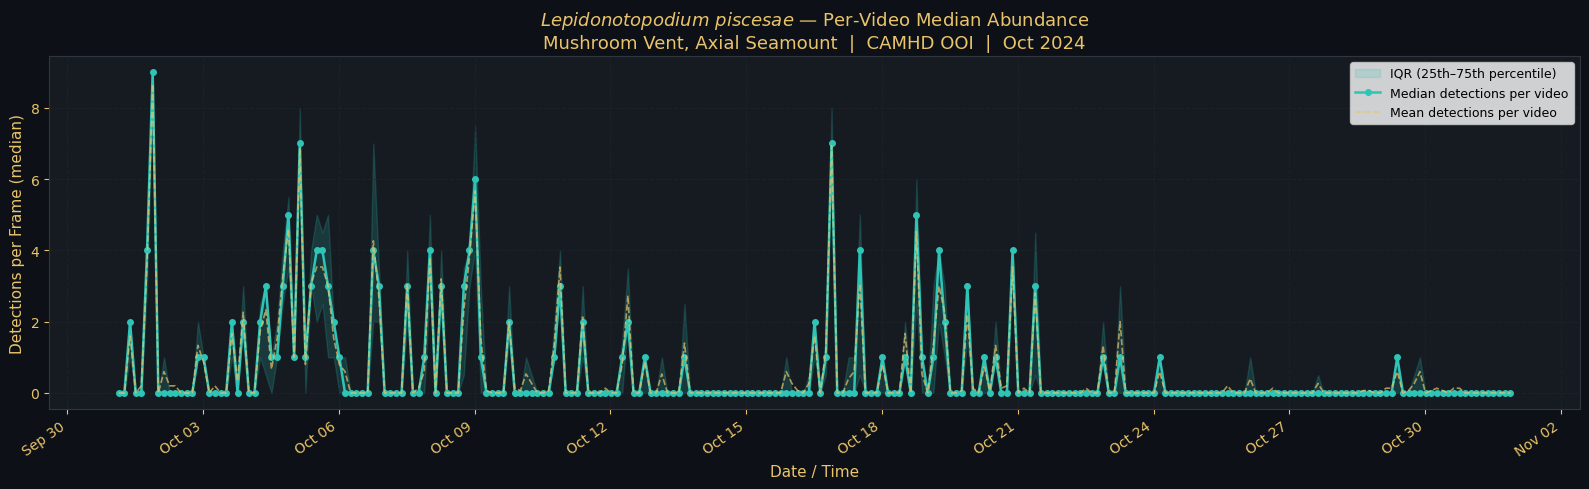

Saved: fig1_per_video_median.png


In [8]:
# ── Chart 1: Per-video median with IQR band ───────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(per_video['datetime'],
                per_video['q25'], per_video['q75'],
                alpha=0.18, color=TEAL, label='IQR (25th–75th percentile)')
ax.plot(per_video['datetime'], per_video['median'],
        color=TEAL, linewidth=1.8, marker='o', markersize=4,
        label='Median detections per video')
ax.plot(per_video['datetime'], per_video['mean'],
        color=GOLD, linewidth=1.2, linestyle='--', alpha=0.7,
        label='Mean detections per video')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date / Time')
ax.set_ylabel('Detections per Frame (median)')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Per-Video Median Abundance'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax.legend(facecolor='white', labelcolor='black', fontsize=9)
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig1_per_video_median.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_per_video_median.png')

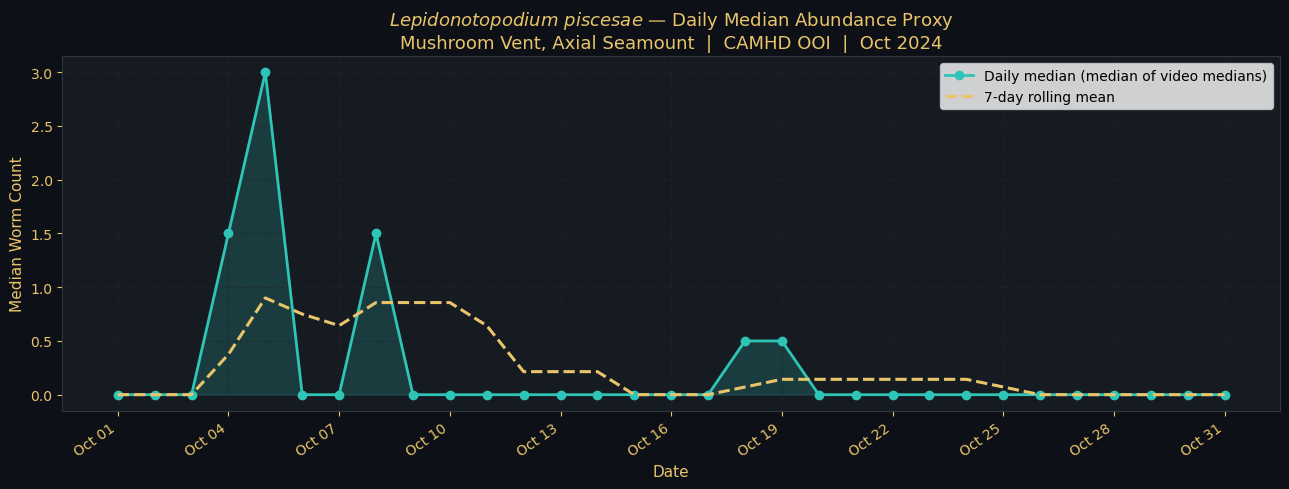

Saved: fig2_daily_median.png


In [9]:
# ── Chart 2: Daily median of medians with rolling mean ───────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(per_day['date'], per_day['daily_median'],
                alpha=0.20, color=TEAL)
ax.plot(per_day['date'], per_day['daily_median'],
        color=TEAL, linewidth=2, marker='o', markersize=6,
        label='Daily median (median of video medians)')

if len(per_day) >= 7:
    rolling = per_day.set_index('date')['daily_median'].rolling('7D').mean()
    ax.plot(rolling.index, rolling.values,
            color=GOLD, linewidth=2.2, linestyle='--',
            label='7-day rolling mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Median Worm Count')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Daily Median Abundance Proxy'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax.legend(facecolor='white', labelcolor='black')
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig2_daily_median.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_daily_median.png')

## 7. Load Manual VIAME Annotations

<span style="font-family: 'Courier New', monospace;">

The VIAME CSV files contain expert human annotations of scale worms from March, June, and August 2023 — the data used to train the Mushroom Model. Each row in a VIAME CSV represents one detection in one frame, so counting rows per frame number gives the human-annotated worm count for that frame.

Because the manual annotations cover different dates than the YOLO detections (Oct 2024), a direct frame-by-frame comparison is not possible. Instead, the **distributions** of per-frame counts are compared — this tells us whether the model produces ecologically plausible counts relative to what a human expert observed.

**VIAME column mapping:**
- Column 0 = track/detection ID
- Column 1 = timestamp within video
- Column 2 = frame number
- Columns 3–6 = bounding box (TL_x, TL_y, BR_x, BR_y)
- Column 7 = confidence
- Column 9 = species label

**Expected output:** Total annotation count, date range covered, and a preview of the parsed table.

</span>

In [10]:
COL_NAMES = [
    'track_id', 'timestamp', 'frame_num',
    'tl_x', 'tl_y', 'br_x', 'br_y',
    'confidence', 'target_length', 'species', 'species_conf'
]

VIAME_REGEX = re.compile(r"CAMHDA301-(\d{8})T(\d{6})")

annot_records = []
csvs = sorted(ANNOT_DIR.glob("*.csv"))
print(f"Loading {len(csvs)} annotation CSVs...\n")

for csv_path in csvs:
    m = VIAME_REGEX.search(csv_path.stem)
    if not m:
        print(f"  WARNING: could not parse date from {csv_path.name} — skipping")
        continue

    vid_date = pd.to_datetime(m.group(1), format='%Y%m%d').date()
    vid_time = m.group(2)

    # Skip the two header/metadata comment lines
    df = pd.read_csv(csv_path, header=None, skiprows=2,
                     names=COL_NAMES, on_bad_lines='skip')

    # Keep only scale_worm rows
    df = df[df['species'].astype(str).str.strip() == 'scale_worm'].copy()
    df['date']     = vid_date
    df['time']     = vid_time
    df['csv_file'] = csv_path.name
    annot_records.append(df)

    print(f"  {csv_path.name}: {len(df)} scale_worm detections")

annot_df = pd.concat(annot_records, ignore_index=True)
annot_df['frame_num'] = pd.to_numeric(annot_df['frame_num'], errors='coerce')
annot_df['date']      = pd.to_datetime(annot_df['date'])

print(f"\nTotal manual detections : {len(annot_df):,}")
print(f"Date range              : {annot_df['date'].min().date()} to {annot_df['date'].max().date()}")
print(f"Unique videos           : {annot_df['csv_file'].nunique()}")
annot_df.head()

Loading 39 annotation CSVs...

  CAMHDA301-20230305T001500_scene1.csv: 2730 scale_worm detections
  CAMHDA301-20230306T001500_scene1.csv: 895 scale_worm detections
  CAMHDA301-20230312T001500_scene1.csv: 927 scale_worm detections
  CAMHDA301-20230313T001500_scene1.csv: 1133 scale_worm detections
  CAMHDA301-20230316T001500_scene1.csv: 2079 scale_worm detections
  CAMHDA301-20230317T001500_scene1.csv: 1400 scale_worm detections
  CAMHDA301-20230318T001500_scene1.csv: 2060 scale_worm detections
  CAMHDA301-20230319T001500_scene1.csv: 1700 scale_worm detections
  CAMHDA301-20230322T001500_scene1.csv: 1352 scale_worm detections
  CAMHDA301-20230323T001500_scene1.csv: 1600 scale_worm detections
  CAMHDA301-20230325T001500_scene1.csv: 742 scale_worm detections
  CAMHDA301-20230326T001500_scene1.csv: 1060 scale_worm detections
  CAMHDA301-20230328T001500_scene1.csv: 714 scale_worm detections
  CAMHDA301-20230329T001500_scene1.csv: 535 scale_worm detections
  CAMHDA301-20230330T001500_scene1.c

,track_id,timestamp,frame_num,tl_x,tl_y,br_x,br_y,confidence,target_length,species,species_conf,date,time,csv_file
0,0,00:00:00.000000,0,1080,330,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
1,0,00:00:00.100000,1,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
2,0,00:00:00.200000,2,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
3,0,00:00:00.300000,3,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv
4,0,00:00:00.400000,4,1080,335,1166,384,1.0,-1,scale_worm,1.0,2023-03-05,001500,CAMHDA301-20230305T001500_scene1.csv


## 8. Compute Manual Per-Frame and Per-Video Counts

<span style="font-family: 'Courier New', monospace;">

The same median-per-video method is applied to the manual annotations. For each annotated video, worm counts are summed per frame, and the median of those counts becomes the abundance proxy. This produces a directly comparable value to the YOLO medians computed in Step 5.

**Expected output:** A summary table of manual per-video medians, and a distribution summary.

</span>

In [11]:
# Per-frame count from manual annotations (one row per frame per video)
manual_per_frame = (
    annot_df.groupby(['csv_file', 'date', 'frame_num'])['track_id']
    .count()
    .reset_index()
    .rename(columns={'track_id': 'det_count'})
)

# Per-video median from manual annotations
manual_per_video = (
    manual_per_frame.groupby(['csv_file', 'date'])['det_count']
    .agg(
        median      = 'median',
        mean        = 'mean',
        std         = 'std',
        min         = 'min',
        max         = 'max',
        q25         = lambda x: x.quantile(0.25),
        q75         = lambda x: x.quantile(0.75),
        frame_count = 'count',
    )
    .reset_index()
    .sort_values('date')
)
manual_per_video['iqr'] = manual_per_video['q75'] - manual_per_video['q25']

print(f"Manual annotations summary")
print(f"  Videos annotated         : {len(manual_per_video)}")
print(f"  Overall median per frame : {manual_per_frame['det_count'].median():.2f}")
print(f"  Overall mean per frame   : {manual_per_frame['det_count'].mean():.2f}")
print(f"  Max in one frame         : {manual_per_frame['det_count'].max()}")
print()
print(manual_per_video[['csv_file','median','mean','std','min','max','frame_count']].to_string(index=False))

Manual annotations summary
  Videos annotated         : 39
  Overall median per frame : 11.00
  Overall mean per frame   : 11.71
  Max in one frame         : 21

                            csv_file  median      mean      std  min  max  frame_count
CAMHDA301-20230305T001500_scene1.csv    21.0 21.000000 0.000000   21   21          130
CAMHDA301-20230306T001500_scene1.csv     7.0  6.532847 3.091856    1   10          137
CAMHDA301-20230312T001500_scene1.csv     9.0  9.000000 0.000000    9    9          103
CAMHDA301-20230313T001500_scene1.csv    11.0 11.000000 0.000000   11   11          103
CAMHDA301-20230316T001500_scene1.csv    21.0 21.000000 0.000000   21   21           99
CAMHDA301-20230317T001500_scene1.csv    14.0 14.000000 0.000000   14   14          100
CAMHDA301-20230318T001500_scene1.csv    20.0 20.000000 0.000000   20   20          103
CAMHDA301-20230319T001500_scene1.csv    17.0 17.000000 0.000000   17   17          100
CAMHDA301-20230322T001500_scene1.csv    13.0 13.000000 

## 9. Manual vs AI Annotations Comparison

<span style="font-family: 'Courier New', monospace;">

Since the manual annotations and YOLO detections cover different time periods, a direct date-matched comparison is not possible. Instead, this section compares the **distributions** of per-frame worm counts between the two methods. If the YOLO model is performing well, its distribution of counts should be ecologically plausible relative to what a human expert observed.

Four panels are shown:

- **Overlaid histograms** — frequency of per-frame detection counts for manual vs YOLO
- **Box plots** — side-by-side summary statistics for both methods
- **Per-video median comparison** — bar chart comparing the median values from each annotated video (manual) against the distribution of YOLO video medians
- **Summary statistics table** — numeric comparison of key metrics between the two methods

</span>

/tmp/ipykernel_373/625935621.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


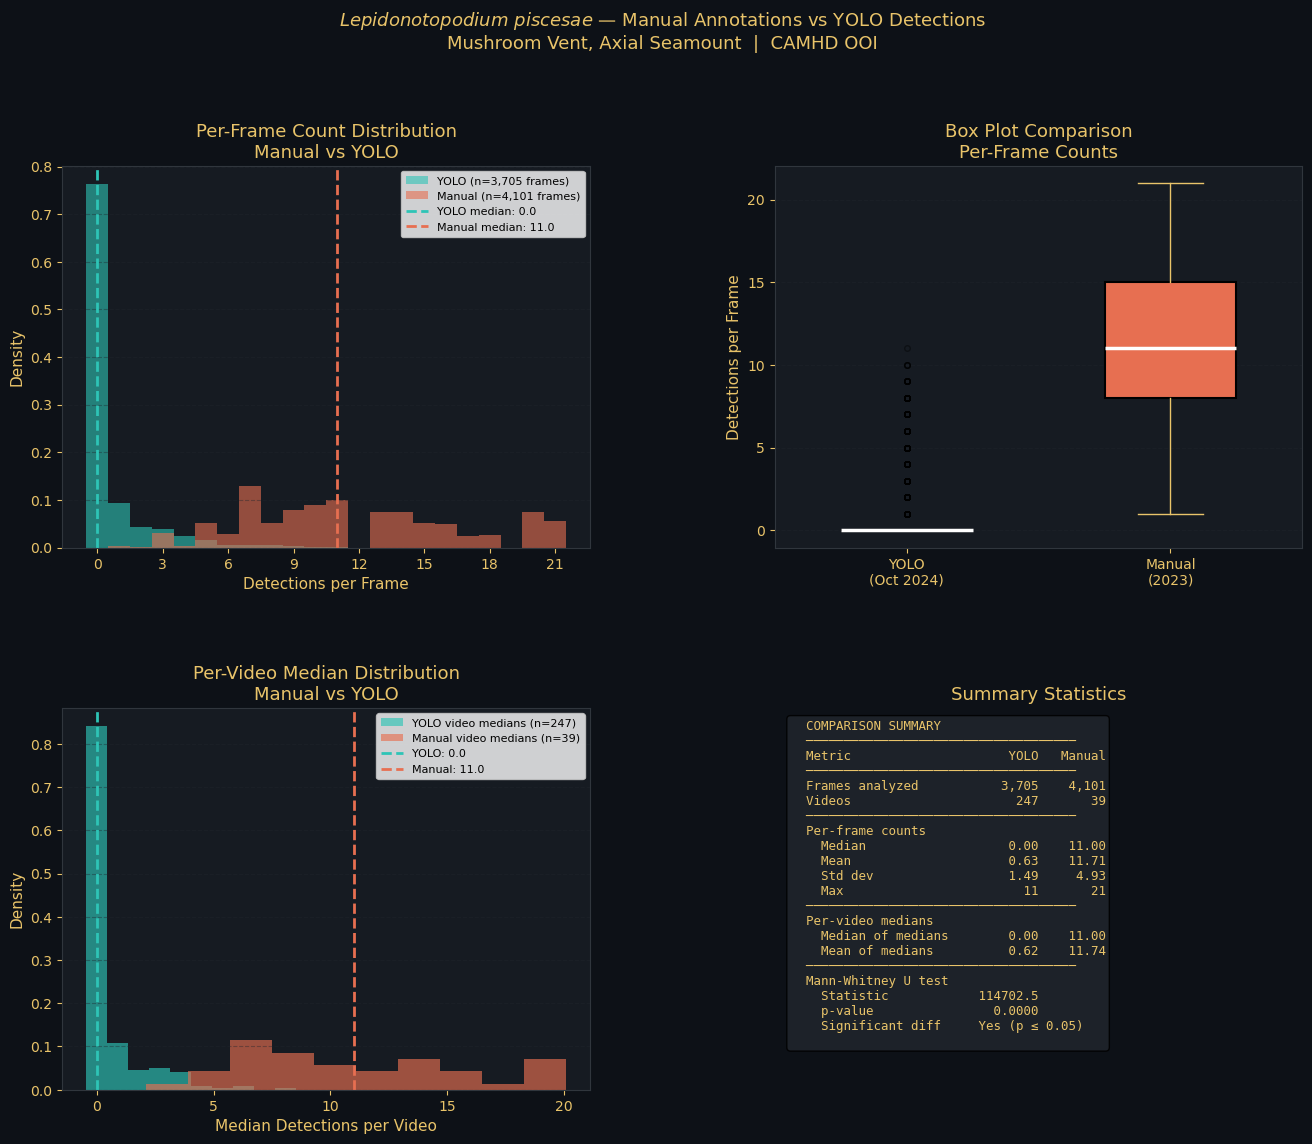

Saved: fig3_manual_vs_ai.png


In [12]:
# Per-frame counts for each method
yolo_counts   = frames_df['det_count'].values
manual_counts = manual_per_frame['det_count'].values

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel 1: Overlaid histograms ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
max_count = max(yolo_counts.max(), manual_counts.max())
bins = range(0, int(max_count) + 2)
ax1.hist(yolo_counts,   bins=bins, color=TEAL,   alpha=0.6,
         label=f'YOLO (n={len(yolo_counts):,} frames)',   density=True, align='left')
ax1.hist(manual_counts, bins=bins, color=ORANGE, alpha=0.6,
         label=f'Manual (n={len(manual_counts):,} frames)', density=True, align='left')
ax1.axvline(np.median(yolo_counts),   color=TEAL,   linewidth=2,
            linestyle='--', label=f'YOLO median: {np.median(yolo_counts):.1f}')
ax1.axvline(np.median(manual_counts), color=ORANGE, linewidth=2,
            linestyle='--', label=f'Manual median: {np.median(manual_counts):.1f}')
ax1.set_xlabel('Detections per Frame')
ax1.set_ylabel('Density')
ax1.set_title('Per-Frame Count Distribution\nManual vs YOLO')
ax1.legend(facecolor='white', labelcolor='black', fontsize=8)
ax1.grid(True, axis='y', alpha=0.4)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Panel 2: Box plots ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bp  = ax2.boxplot(
    [yolo_counts, manual_counts],
    patch_artist=True, vert=True, widths=0.5,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2.5, color='white'),
    whiskerprops=dict(color=GOLD),
    capprops=dict(color=GOLD),
    flierprops=dict(marker='o', markersize=4, alpha=0.4)
)
bp['boxes'][0].set_facecolor(TEAL)
bp['boxes'][1].set_facecolor(ORANGE)
bp['fliers'][0].set_color(TEAL)
bp['fliers'][1].set_color(ORANGE)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['YOLO\n(Oct 2024)', 'Manual\n(2023)'])
ax2.set_ylabel('Detections per Frame')
ax2.set_title('Box Plot Comparison\nPer-Frame Counts')
ax2.grid(True, axis='y', alpha=0.4)

# ── Panel 3: Per-video medians comparison ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
yolo_medians   = per_video['median'].values
manual_medians = manual_per_video['median'].values

ax3.hist(yolo_medians,   bins=10, color=TEAL,   alpha=0.65,
         label=f'YOLO video medians (n={len(yolo_medians)})',   density=True, align='left')
ax3.hist(manual_medians, bins=10, color=ORANGE, alpha=0.65,
         label=f'Manual video medians (n={len(manual_medians)})', density=True, align='left')
ax3.axvline(np.median(yolo_medians),   color=TEAL,   linewidth=2,
            linestyle='--', label=f'YOLO: {np.median(yolo_medians):.1f}')
ax3.axvline(np.median(manual_medians), color=ORANGE, linewidth=2,
            linestyle='--', label=f'Manual: {np.median(manual_medians):.1f}')
ax3.set_xlabel('Median Detections per Video')
ax3.set_ylabel('Density')
ax3.set_title('Per-Video Median Distribution\nManual vs YOLO')
ax3.legend(facecolor='white', labelcolor='black', fontsize=8)
ax3.grid(True, axis='y', alpha=0.4)

# ── Panel 4: Summary statistics table ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Mann-Whitney U test (non-parametric — appropriate since counts may not be normal)
mw_stat, mw_p = stats.mannwhitneyu(yolo_counts, manual_counts, alternative='two-sided')
sig_str = 'Yes (p ≤ 0.05)' if mw_p <= 0.05 else 'No (p > 0.05)'

table_text = (
    f"  COMPARISON SUMMARY\n"
    f"  {'─'*36}\n"
    f"  {'Metric':<22} {'YOLO':>8} {'Manual':>8}\n"
    f"  {'─'*36}\n"
    f"  {'Frames analyzed':<22} {len(yolo_counts):>8,} {len(manual_counts):>8,}\n"
    f"  {'Videos':<22} {len(per_video):>8} {len(manual_per_video):>8}\n"
    f"  {'─'*36}\n"
    f"  Per-frame counts\n"
    f"  {'  Median':<22} {np.median(yolo_counts):>8.2f} {np.median(manual_counts):>8.2f}\n"
    f"  {'  Mean':<22} {np.mean(yolo_counts):>8.2f} {np.mean(manual_counts):>8.2f}\n"
    f"  {'  Std dev':<22} {np.std(yolo_counts):>8.2f} {np.std(manual_counts):>8.2f}\n"
    f"  {'  Max':<22} {yolo_counts.max():>8} {manual_counts.max():>8}\n"
    f"  {'─'*36}\n"
    f"  Per-video medians\n"
    f"  {'  Median of medians':<22} {np.median(yolo_medians):>8.2f} {np.median(manual_medians):>8.2f}\n"
    f"  {'  Mean of medians':<22} {np.mean(yolo_medians):>8.2f} {np.mean(manual_medians):>8.2f}\n"
    f"  {'─'*36}\n"
    f"  Mann-Whitney U test\n"
    f"  {'  Statistic':<22} {mw_stat:>8.1f}\n"
    f"  {'  p-value':<22} {mw_p:>8.4f}\n"
    f"  {'  Significant diff':<22} {sig_str:>8}\n"
)

ax4.text(0.03, 0.97, table_text, transform=ax4.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace', color=GOLD,
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.85))
ax4.set_title('Summary Statistics')

fig.suptitle(
    r'$Lepidonotopodium\ piscesae$ — Manual Annotations vs YOLO Detections'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI',
    fontsize=13, y=1.01
)
fig.patch.set_facecolor('#0d1117')
for a in [ax1, ax2, ax3, ax4]:
    a.set_facecolor('#161b22')

fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig3_manual_vs_ai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_manual_vs_ai.png')

## 10. Summary Statistics

<span style="font-family: 'Courier New', monospace;">

A full printed summary of the abundance analysis, including the median abundance proxy for the month, the range of per-video medians, and a comparison of detection rates between the YOLO model and manual annotations. Use these values when writing up results for AGU.

</span>

In [13]:
print('=' * 58)
print('  MEDIAN ABUNDANCE ANALYSIS — SUMMARY')
print('=' * 58)
print(f'  Species   : Lepidonotopodium piscesae')
print(f'  Site      : Mushroom Vent, Axial Seamount')
print(f'  Period    : {START_DATE}  →  {END_DATE}')
print('-' * 58)
print(f'  YOLO detections (Oct 2024)')
print(f'    Videos processed          : {len(per_video)}')
print(f'    Total frames analyzed     : {len(frames_df):,}')
print(f'    Median of video medians   : {per_video["median"].median():.2f} worms/frame')
print(f'    Mean of video medians     : {per_video["median"].mean():.2f} worms/frame')
print(f'    Highest video median      : {per_video["median"].max():.1f} ({per_video.loc[per_video["median"].idxmax(), "video"]})')
print(f'    Lowest video median       : {per_video["median"].min():.1f}')
print('-' * 58)
print(f'  Manual annotations (2023)')
print(f'    Videos annotated          : {len(manual_per_video)}')
print(f'    Total frames annotated    : {len(manual_per_frame):,}')
print(f'    Median of video medians   : {manual_per_video["median"].median():.2f} worms/frame')
print(f'    Mean of video medians     : {manual_per_video["median"].mean():.2f} worms/frame')
print(f'    Highest video median      : {manual_per_video["median"].max():.1f}')
print('-' * 58)
print(f'  Difference (YOLO − Manual)')
diff = per_video['median'].median() - manual_per_video['median'].median()
pct  = (diff / manual_per_video['median'].median() * 100) if manual_per_video['median'].median() != 0 else float('nan')
print(f'    Median difference         : {diff:+.2f} worms/frame')
print(f'    Relative difference       : {pct:+.1f}%')
print('=' * 58)
print()
print('NOTE: YOLO and manual annotations cover different time')
print('periods and cannot be directly matched frame-by-frame.')
print('The comparison is distributional — showing whether the')
print('model produces ecologically plausible counts relative')
print('to expert human observations.')

  MEDIAN ABUNDANCE ANALYSIS — SUMMARY
  Species   : Lepidonotopodium piscesae
  Site      : Mushroom Vent, Axial Seamount
  Period    : 2024-10-01  →  2024-10-31
----------------------------------------------------------
  YOLO detections (Oct 2024)
    Videos processed          : 247
    Total frames analyzed     : 3,705
    Median of video medians   : 0.00 worms/frame
    Mean of video medians     : 0.62 worms/frame
    Highest video median      : 9.0 (CAMHDA301-20241001T211500)
    Lowest video median       : 0.0
----------------------------------------------------------
  Manual annotations (2023)
    Videos annotated          : 39
    Total frames annotated    : 4,101
    Median of video medians   : 11.00 worms/frame
    Mean of video medians     : 11.74 worms/frame
    Highest video median      : 21.0
----------------------------------------------------------
  Difference (YOLO − Manual)
    Median difference         : -11.00 worms/frame
    Relative difference       : -100.0%

N

In [14]:
import subprocess
from pathlib import Path

test_vid = sorted(Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/").rglob("CAMHDA301-202410*.mp4"))[0]

result = subprocess.run(
    ["ffprobe", "-v", "error", "-show_entries", "format=duration",
     "-of", "default=noprint_wrappers=1:nokey=1", str(test_vid)],
    capture_output=True, text=True
)
duration = float(result.stdout.strip())
print(f"Video     : {test_vid.name}")
print(f"Duration  : {duration:.1f} seconds ({duration/60:.1f} minutes)")
print()
print(f"Proposed 15-minute window:")
print(f"  Start : 305s  ({305/60:.1f} min into video)")
print(f"  End   : {305+900}s ({(305+900)/60:.1f} min into video)")
print()
if duration >= 305 + 900:
    print("✓ Video is long enough to support this window")
else:
    print(f"✗ Video ends at {duration:.0f}s — window would need to end at {duration:.0f}s instead of {305+900}s")

Video     : CAMHDA301-20241001T010000.mp4
Duration  : 3591.6 seconds (59.9 minutes)

Proposed 15-minute window:
  Start : 305s  (5.1 min into video)
  End   : 1205s (20.1 min into video)

✓ Video is long enough to support this window


In [15]:
import pandas as pd
from pathlib import Path

csv = sorted(Path("/home/jovyan/scaleworm_starter/baseline/annotations_scene1").glob("*.csv"))[0]
df  = pd.read_csv(csv, header=None, skiprows=2)
df.columns = ['track_id','timestamp','frame_num','tl_x','tl_y',
              'br_x','br_y','confidence','target_length','species','species_conf']

print(f"CSV        : {csv.name}")
print(f"Rows       : {len(df)}")
print(f"Frame range: {df['frame_num'].min()} to {df['frame_num'].max()}")
print(f"Time range : {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"At 10fps, max frame {df['frame_num'].max()} = {int(df['frame_num'].max())/10:.1f} seconds into video")

CSV        : CAMHDA301-20230305T001500_scene1.csv
Rows       : 2730
Frame range: 0 to 129
Time range : 00:00:00.000000 to 00:00:12.900000
At 10fps, max frame 129 = 12.9 seconds into video
